<a href="https://colab.research.google.com/github/aryac-2006/Machine-Learning-Model/blob/main/Task_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import make_blobs

# Create synthetic dataset
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.70,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

# Display first 10 rows
print(df.head(10))

# Shape of dataset
print("\nShape:", df.shape)

   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846

Shape: (500, 2)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[["Feature1", "Feature2"]])

# First 5 rows
print(pd.DataFrame(X_scaled, columns=["Feature1", "Feature2"]).head())

   Feature1  Feature2
0 -0.888474  0.629907
1 -1.028908 -1.562875
2  1.831069 -0.235113
3  0.116557  0.814671
4 -0.506563 -1.602370


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df.head(10))

   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


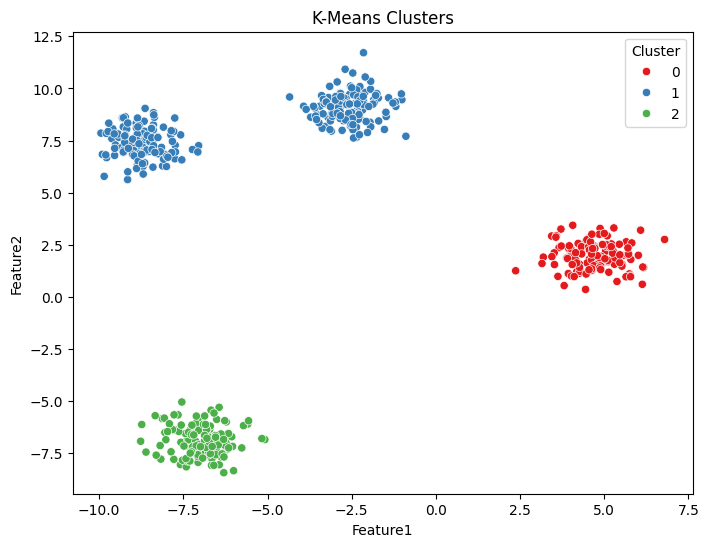

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Cluster",
    palette="Set1"
)

plt.title("K-Means Clusters")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

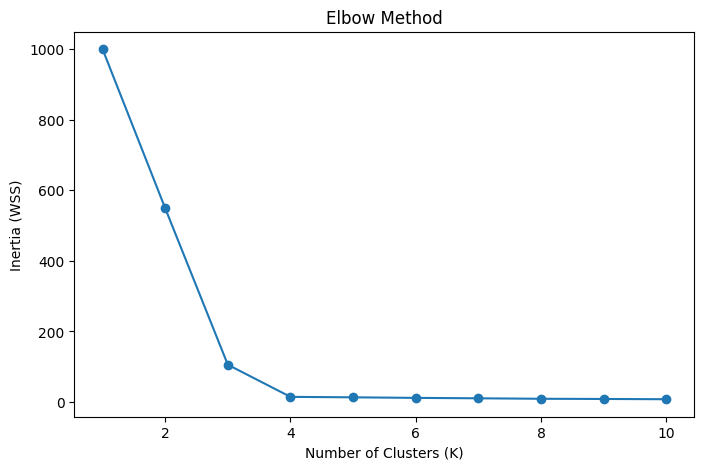


Optimal K looks like: 4


In [ ]:
wss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    model.fit(X_scaled)
    wss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")

plt.show()

print("\nOptimal K looks like: 4")

In [ ]:
final_model = KMeans(
    n_clusters=4,
    random_state=42
)

final_clusters = final_model.fit_predict(X_scaled)

df["FinalCluster"] = final_clusters

print(df["FinalCluster"].value_counts())

FinalCluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


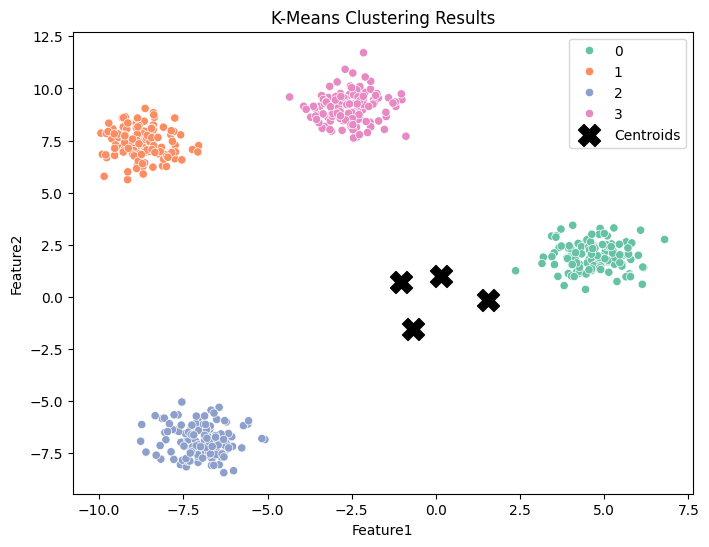

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="FinalCluster",
    palette="Set2"
)

plt.scatter(
    final_model.cluster_centers_[:,0],
    final_model.cluster_centers_[:,1],
    s=250,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clustering Results")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()

plt.show()

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Select numerical features
X = iris_df

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

iris_df["Cluster"] = kmeans.fit_predict(X_scaled)

print(iris_df["Cluster"].value_counts())

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


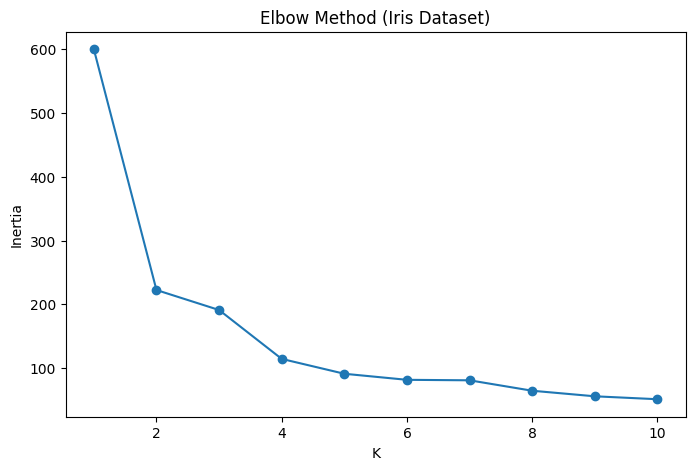


 FinalCluster
0    96
1    33
2    21
Name: count, dtype: int64


In [ ]:
wss = []

for k in range(1,11):
    km = KMeans(
        n_clusters=k,
        random_state=42
    )
    km.fit(X_scaled)
    wss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wss, marker="o")

plt.title("Elbow Method (Iris Dataset)")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.show()

# Final model
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

iris_df["FinalCluster"] = final_kmeans.fit_predict(X_scaled)

print("\n", iris_df["FinalCluster"].value_counts())

Saving Mall_Customers.csv to Mall_Customers (2).csv

----------------------------< Fist 10 rows >---------------------------

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

---------------- Dataset Information ----------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)     

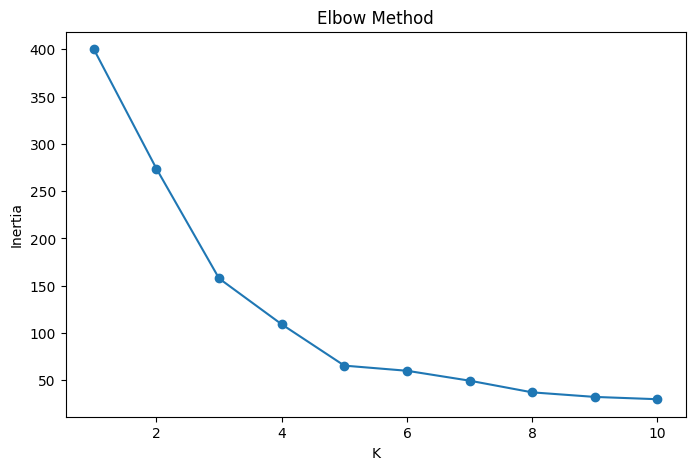

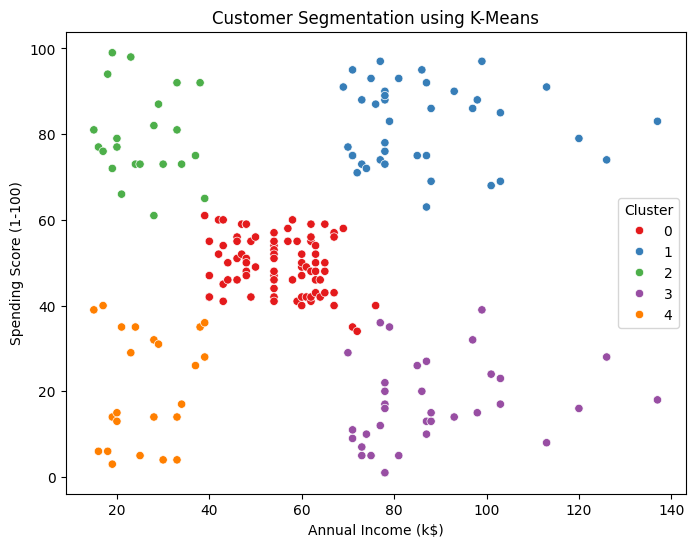

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

filepath = "./ford_car_dataset.csv"

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Display the first 5 rows
print("\n----------------------------< Fist 10 rows >---------------------------\n")
print(df.head())

# Display Dataset Information
print("\n---------------- Dataset Information ----------------\n")
print(df.info())

# Statistical summary of numeric columns
print("\n<<<<<<<<<<<<<< Statistical summary >>>>>>>>>>>>>\n")
print(df.describe())
print()

# Select numerical features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Elbow Method
wss = []

for k in range(1,11):
    km = KMeans(
        n_clusters=k,
        random_state=42
    )
    km.fit(X_scaled)
    wss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wss, marker="o")

plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.show()

# Final Model
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segmentation using K-Means")

plt.show()